In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

In [2]:
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "requirements.txt").exists() else Path.cwd().parent

FILE_PATH = PROJECT_ROOT / "data" / "challenger_mastery.parquet"

if not FILE_PATH.exists():
    print(f"Error: Could not find data at {FILE_PATH}")
    print(f"Current Working Directory: {os.getcwd()}")
else:
    print(f"Successfully located data at: {FILE_PATH}")

df = pd.read_parquet(FILE_PATH)
df.head()

Successfully located data at: c:\Users\LEGION\Documents\GitHub\riot-challenger-etl\data\challenger_mastery.parquet


,summoner_name,ladder_rank,champion_id,champion_name,mastery_level,total_mastery_points,last_played_utc
0,tukaan#tukan,1,145,Kai'Sa,117,1257250,2026-04-24 09:18:48+00:00
1,tukaan#tukan,1,81,Ezreal,106,1133705,2026-04-23 21:34:37+00:00
2,tukaan#tukan,1,18,Tristana,66,698639,2026-04-13 08:57:46+00:00
3,G2 SkewMond#3327,2,234,Viego,34,340610,2026-04-25 20:53:10+00:00
4,G2 SkewMond#3327,2,254,Vi,32,322861,2026-04-26 09:57:52+00:00


In [3]:
print(f"Dataset Shape: {df.shape}")
print(f"Unique Players: {df['summoner_name'].nunique()}")

display(df.info())

display(df.describe(percentiles=[.25, .5, .75, .9, .99]).T)

Dataset Shape: (150, 7)
Unique Players: 50
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype              
---  ------                --------------  -----              
 0   summoner_name         150 non-null    object             
 1   ladder_rank           150 non-null    int64              
 2   champion_id           150 non-null    int64              
 3   champion_name         150 non-null    object             
 4   mastery_level         150 non-null    int64              
 5   total_mastery_points  150 non-null    int64              
 6   last_played_utc       150 non-null    datetime64[ns, UTC]
dtypes: datetime64[ns, UTC](1), int64(4), object(2)
memory usage: 8.3+ KB


None

,count,mean,std,min,25%,50%,75%,90%,99%,max
ladder_rank,150.0,25.500000,14.479214,1.0,13.00,25.5,38.00,45.1,50.00,50.0
champion_id,150.0,213.253333,231.251720,5.0,64.00,116.0,245.75,526.0,893.00,910.0
mastery_level,150.0,49.906667,51.715581,5.0,24.00,38.0,56.00,92.1,251.51,430.0
total_mastery_points,150.0,521199.213333,568890.249491,30821.0,233953.25,388050.0,598640.50,986721.3,2738723.24,4701867.0


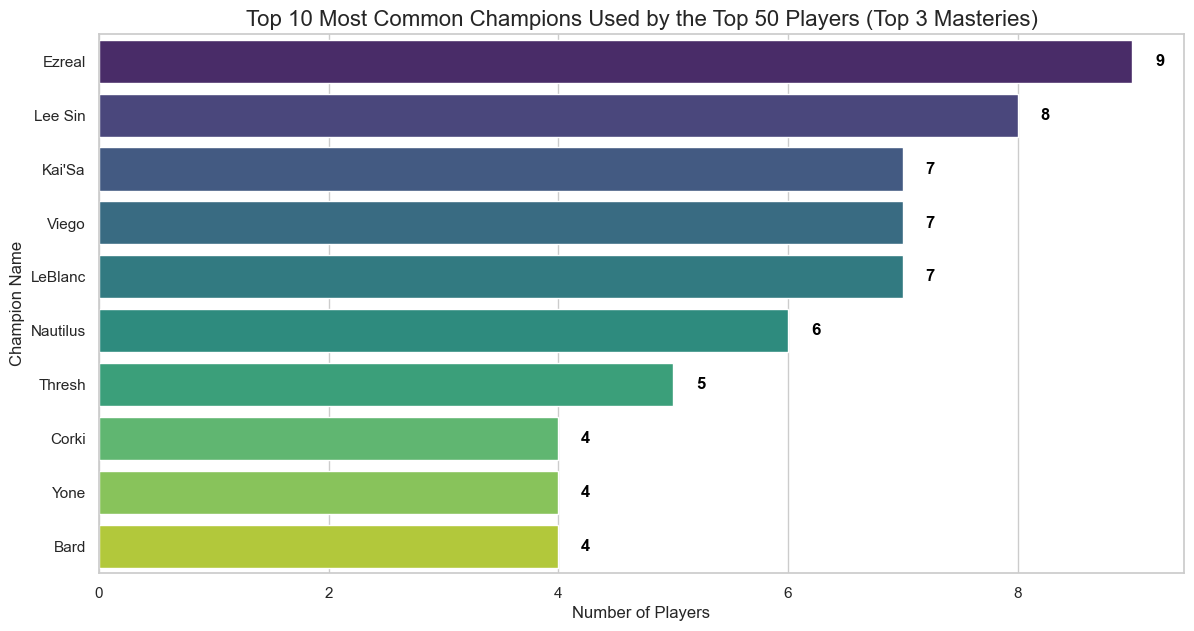

In [4]:
meta_data = df['champion_name'].value_counts().head(10)

plt.figure(figsize=(14, 7))
sns.barplot(x=meta_data.values, y=meta_data.index, palette="viridis", hue=meta_data.index)

plt.title("Top 10 Most Common Champions Used by the Top 50 Players (Top 3 Masteries)", fontsize=16)
plt.xlabel("Number of Players", fontsize=12)
plt.ylabel("Champion Name", fontsize=12)

for i, v in enumerate(meta_data.values):
    plt.text(v + 0.2, i, str(v), color='black', va='center', fontweight='bold')

plt.show()

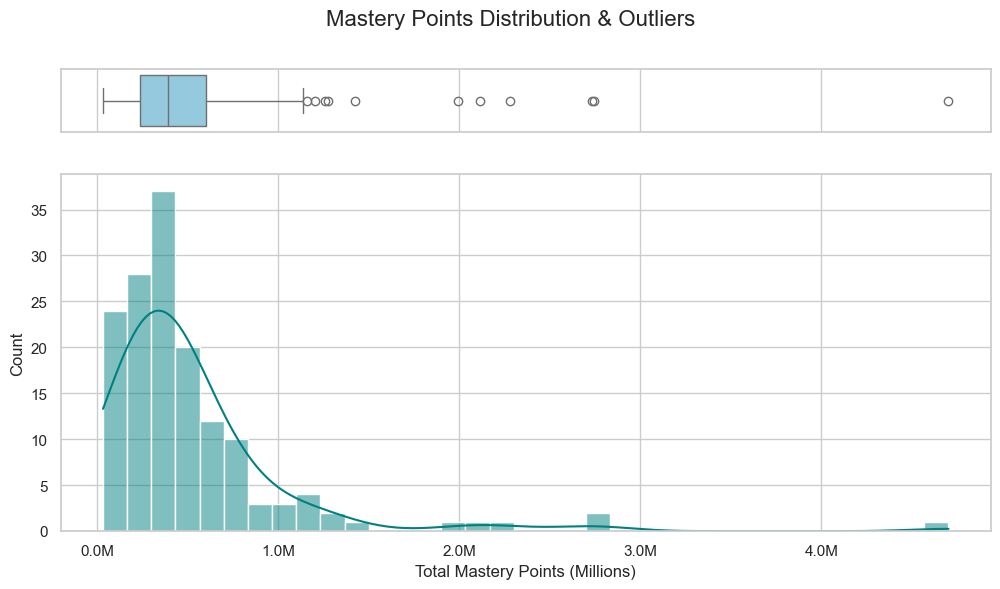

In [5]:
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)})

sns.boxplot(x=df["total_mastery_points"], ax=ax_box, color="skyblue")
ax_box.set(xlabel='')

sns.histplot(x=df["total_mastery_points"], ax=ax_hist, kde=True, color="teal")

ax_hist.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

ax_hist.xaxis.set_major_locator(ticker.MultipleLocator(1000000))

plt.suptitle("Mastery Points Distribution & Outliers", fontsize=16)
plt.xlabel("Total Mastery Points (Millions)", fontsize=12)
plt.show()

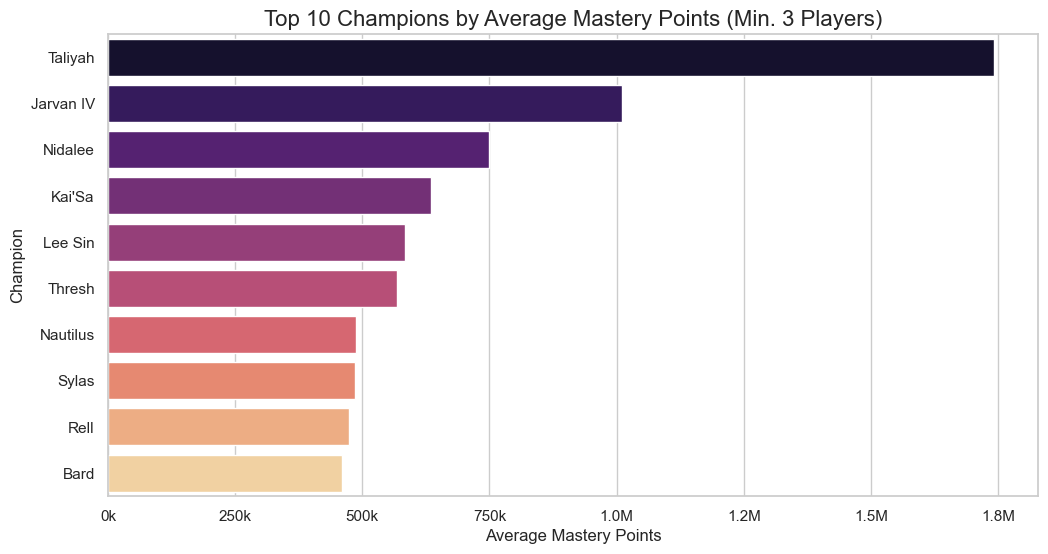

In [6]:
champ_stats = df.groupby('champion_name').agg(
    avg_mastery=('total_mastery_points', 'mean'),
    player_count=('summoner_name', 'count')
).query('player_count >= 3').sort_values('avg_mastery', ascending=False).head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x=champ_stats['avg_mastery'], 
    y=champ_stats.index, 
    hue=champ_stats.index,
    palette="magma",
    legend=False
)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M' if x >= 1e6 else f'{int(x/1000)}k'))

plt.title("Top 10 Champions by Average Mastery Points (Min. 3 Players)", fontsize=16)
plt.xlabel("Average Mastery Points", fontsize=12)
plt.ylabel("Champion", fontsize=12)
plt.show()

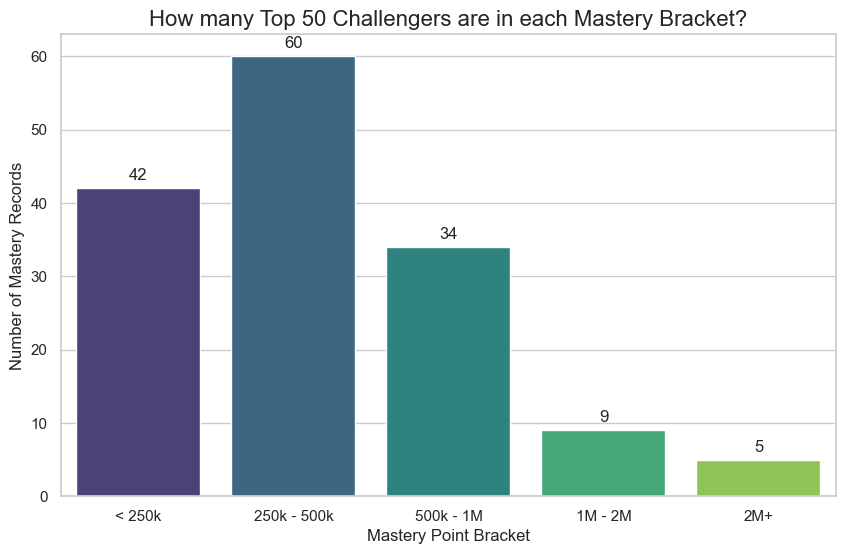

In [7]:
bins = [0, 250000, 500000, 1000000, 2000000, float('inf')]
labels = ['< 250k', '250k - 500k', '500k - 1M', '1M - 2M', '2M+']
df['mastery_bracket'] = pd.cut(df['total_mastery_points'], bins=bins, labels=labels)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df, 
    x='mastery_bracket', 
    hue='mastery_bracket',
    palette="viridis", 
    order=labels,
    legend=False
)

plt.title("How many Top 50 Challengers are in each Mastery Bracket?", fontsize=16)
plt.xlabel("Mastery Point Bracket", fontsize=12)
plt.ylabel("Number of Mastery Records", fontsize=12)

for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}', 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', xytext=(0, 9), textcoords='offset points'
    )

plt.show()